# Imports

In [1]:
import os

import cv2
from PIL import Image, ImageDraw, ImageFont
from torchvision.transforms import ToPILImage

from torchvision.transforms import v2 as T
import torchvision.transforms as transforms

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from tqdm.notebook import tqdm

# Setup

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print('Device:', device)

Device: cuda


## Loat MOT16 Dataset

In [4]:
!cp '/content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/raw_data/MOT16.zip' 'MOT16.zip'

In [5]:
!unzip 'MOT16.zip'

Streaming output truncated to the last 5000 lines.
  inflating: MOT16/train/MOT16-11/img1/000188.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000188.jpg  
  inflating: MOT16/train/MOT16-11/img1/000836.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000836.jpg  
  inflating: MOT16/train/MOT16-11/img1/000639.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000639.jpg  
  inflating: MOT16/train/MOT16-11/img1/000605.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000605.jpg  
  inflating: MOT16/train/MOT16-11/img1/000163.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000163.jpg  
  inflating: MOT16/train/MOT16-11/img1/000177.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000177.jpg  
  inflating: MOT16/train/MOT16-11/img1/000611.jpg  
  inflating: __MACOSX/MOT16/train/MOT16-11/img1/._000611.jpg  
  inflating: MOT16/train/MOT16-05/det/det.txt  
  inflating: __MACOSX/MOT16/train/MOT16-05/det/._det.txt  
  inflating: MOT16/train/MOT16-05/gt/

## Load Faster-RCNN Model

In [6]:
!cp '/content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/rcnn_model/best_model/fine_tuned_faster_rcnn_state_dict.pth' 'fine_tuned_faster_rcnn_state_dict.pth'

In [7]:
num_classes = 2

# Load in empty faster rcnn model if your using state dict
rcnn_model = fasterrcnn_resnet50_fpn(pretrained=False)

in_features = rcnn_model.roi_heads.box_predictor.cls_score.in_features
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 127MB/s]


In [8]:
# Load the state_dict
rcnn_model.load_state_dict(torch.load("/content/fine_tuned_faster_rcnn_state_dict.pth", map_location=torch.device(device)))

rcnn_model.to(device)
rcnn_model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

## Load Similarity Model

In [9]:
class Siamese_Network(nn.Module):
    def __init__(self):
        super(Siamese_Network, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 256)

    def forward_one(self, x):
        x = F.relu(self.pool(self.conv1(x)))   # 16 → 8
        x = F.relu(self.pool(self.conv2(x)))   # 8 → 4
        x = F.relu(self.conv3(x))              # 4 → 4

        x = self.gap(x)                        # 4×4 → 1×1
        x = x.view(x.size(0), -1)              # (B, 128)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return F.normalize(x, p=2, dim=1)

    def forward(self, input1, input2):
        return self.forward_one(input1), self.forward_one(input2)

In [10]:
!cp '/content/drive/MyDrive/COMP-SCI 5567 - Deep Learning/Project/similarity_model/best_model/similarity_model_state_dict.pth' 'similarity_model_state_dict.pth'

In [11]:
similarity_model = Siamese_Network()

In [12]:
state_dict = torch.load("similarity_model_state_dict.pth", map_location=device)
similarity_model.load_state_dict(state_dict)

similarity_model.to(device)
similarity_model.eval()

Siamese_Network(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
)

# Helper Functions

In [13]:
rcnn_transforms = T.Compose([
  T.ToImage(),
  T.ToDtype(torch.float32, scale=True)
])

In [14]:
similarity_transforms = transforms.Compose([
    transforms.Resize((128, 64)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

In [15]:
# Creates photo with bboxes from origional img and model predictions
def crop_persons_from_prediction(img_path, boxes, score_thresh=0.8):
  img = Image.open(img_path).convert("RGB")

  if img is None:
    print("Failed to read image at ", img_path)
    return

  persons = []

  # Draw boxes
  for i, box in enumerate(boxes):
    x1, y1, x2, y2 = box.tolist()

    cropped_image = img.crop((x1, y1, x2, y2))
    persons.append(cropped_image)

  return persons, boxes

In [16]:
def show_person(img_tensor):
  img = img_tensor.clone().cpu().squeeze(0)  # remove batch dim

  # ImageNet normalization
  mean = [0.485, 0.456, 0.406]
  std = [0.229, 0.224, 0.225]

  for t, m, s in zip(img, mean, std):
      t.mul_(s).add_(m)

  img_pil = ToPILImage()(img)
  display(img_pil)

In [17]:
# Creates video mp4 from many frames
def create_video_from_frames(frames_dir_path, output_filepath, video_name="video", frame_rate=30):
  # Create VideoWriter
  fourcc = cv2.VideoWriter_fourcc(*"mp4v")

  files = os.listdir(frames_dir_path)
  files = [
      os.path.join(frames_dir_path, f)
      for f in os.listdir(frames_dir_path)
      if os.path.isfile(os.path.join(frames_dir_path, f))
  ]
  files = sorted(files, key=lambda x: int(os.path.basename(x).split('.')[0]))

  first_frame = cv2.imread(files[0])
  height, width, _ = first_frame.shape

  os.makedirs(output_filepath, exist_ok=True)

  output_file = os.path.join(output_filepath, f"{video_name}.mp4")
  out = cv2.VideoWriter(output_file, fourcc, frame_rate, (width, height))

  for file in files:
    frame = cv2.imread(file)

    if frame is None:
      print("Failed to read frame:", i)
      continue

    out.write(frame)

  out.release()

In [18]:
def get_persons_from_frame(img_path, threshold=0.8):
  img_pil = Image.open(img_path).convert('RGB')

  img_tensor = rcnn_transforms(img_pil)

  img_tensor = img_tensor.to(device)

  with torch.no_grad():
    prediction = rcnn_model([img_tensor])

  boxes = prediction[0]["boxes"].cpu()
  labels = prediction[0]["labels"].cpu()
  scores = prediction[0]["scores"].cpu()

  keep = scores >= threshold

  boxes = boxes[keep]
  labels = labels[keep]
  scores = scores[keep]

  persons, boxes = crop_persons_from_prediction(img_path, boxes)

  return persons, boxes

In [138]:
def draw_frame(img_path, boxes, target_box, best_sim, second_best_sim, orig_sim, target_lost_frames):
    img_pil = Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img_pil)
    width, height = img_pil.size

    font_path = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"

    try:
      font = ImageFont.truetype(font_path, 12)
    except:
      font = ImageFont.load_default()

    # not target box
    for box in boxes:
      x1, y1, x2, y2 = box
      draw.rectangle([x1, y1, x2, y2], outline="green", width=3)

    if target_box is not None:
      x1, y1, x2, y2 = target_box
      # target_box
      draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
      # target_label
      draw.text((x1, y1 - font.size), "TARGET", fill="yellow", font=font)

    # draw text data
    try:
      font = ImageFont.truetype(font_path, 32)
    except:
      font = ImageFont.load_default()
    line_spacing = font.size + 10
    margin = 40

    stats = [
        f"Best Sim: {best_sim:.3f}",
        f"2nd Best: {second_best_sim:.3f}",
        f"Orig Sim: {orig_sim:.3f}"
    ]

    for i, text in enumerate(reversed(stats)):
      y_pos = height - margin - (i * line_spacing)
      draw.text((margin, y_pos), text, fill="white", font=font)

    lost_text = f"Frames Lost: {target_lost_frames}"
    left, top, right, bottom = draw.textbbox((0, 0), lost_text, font=font)
    text_width = right - left

    draw.text((width - text_width - margin, height - margin),
              lost_text,
              fill="red" if target_lost_frames > 0 else "cyan",
              font=font)

    return img_pil

# Video

In [150]:
frames_dir_path = f"/content/MOT16/test/MOT16-01/img1/"

imgs = os.listdir(frames_dir_path)
imgs = [
    os.path.join(frames_dir_path, f)
    for f in os.listdir(frames_dir_path)
    if os.path.isfile(os.path.join(frames_dir_path, f))
]
img_paths = sorted(imgs)

In [151]:
# img_paths = img_paths[:50] # Fore testing only

In [152]:
FRAMES_SAVE_LOCATION = "/content/OutputFrames"
# Create a new folder in the current working directory
try:
    os.mkdir(FRAMES_SAVE_LOCATION)
    print(f"Folder '{FRAMES_SAVE_LOCATION}' created.")
except FileExistsError:
    print(f"Folder '{FRAMES_SAVE_LOCATION}' already exists.")
except FileNotFoundError:
    print(f"Parent directory does not exist.")

Folder '/content/OutputFrames' already exists.


In [172]:
persons, _ = get_persons_from_frame(img_paths[0])

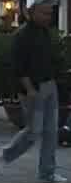

In [173]:
persons[0]

In [174]:
target = persons[0]

In [175]:
same_threshold = 0.9
diff_threshold = 0.02
orig_sim_threshold = 0.75
momentum = 0.8
target_emb = None
original_target_emb = None
target_lost_frames = 0
target_lost_frames_threshold = 15

pbar = tqdm(range(len(img_paths)))
for i, img_path in enumerate(img_paths):
  persons, boxes = get_persons_from_frame(img_path)

  if target_emb is None:
    if not isinstance(target, torch.Tensor):
      target = similarity_transforms(target)
      target = target.unsqueeze(0).to(device)

    with torch.no_grad():
      target_emb = similarity_model.forward_one(target)
      target_emb = F.normalize(target_emb, dim=1)
      original_target_emb = target_emb.clone()

  sim_scores = []
  emb_candidates = []

  for person in persons:
    person = similarity_transforms(person)
    person = person.unsqueeze(0).to(device)

    with torch.no_grad():
      emb = similarity_model.forward_one(person)
      emb = F.normalize(emb, dim=1)

    emb_candidates.append(emb)

  for emb in emb_candidates:
    sim = F.cosine_similarity(emb, target_emb, dim=1).item()
    sim_scores.append(sim)

  indexed_scores = list(enumerate(sim_scores))
  sorted_scores = sorted(indexed_scores, key=lambda x: x[1], reverse=True)
  best_idx, best_score = sorted_scores[0]
  if len(sorted_scores) > 1:
    second_best_idx, second_best_score = sorted_scores[1]
  else:
    second_best_score, second_best_idx = 0.0, -1

  best_sim_score_index = best_idx
  second_best_sim_score_index = second_best_idx

  best_emb = emb_candidates[best_sim_score_index]
  orig_sim = F.cosine_similarity(best_emb, original_target_emb, dim=1).item()

  if (sim_scores[best_sim_score_index] > same_threshold and
      (sim_scores[best_sim_score_index] - sim_scores[second_best_sim_score_index]) >= diff_threshold and
      orig_sim > orig_sim_threshold and
      target_lost_frames < target_lost_frames_threshold):

    target_emb = momentum * target_emb + (1 - momentum) * best_emb
    target_emb = F.normalize(target_emb, dim=1)

    target = persons[best_sim_score_index]
    target_box = boxes[best_sim_score_index]

    target_lost_frames = 0
  else:
    target_box = None
    target_lost_frames += 1

  frame = draw_frame(
      img_path=img_path,
      boxes=boxes,
      target_box=target_box,
      best_sim=best_score,
      second_best_sim=second_best_score,
      orig_sim=orig_sim,
      target_lost_frames=target_lost_frames
  )

  frame.save(f"{FRAMES_SAVE_LOCATION}/{i}.png")

  pbar.update(1)

  0%|          | 0/450 [00:00<?, ?it/s]

In [176]:
create_video_from_frames(
    frames_dir_path="/content/OutputFrames",
    output_filepath="/content/"
)

In [177]:
!zip -r "output_frames.zip" "/content/OutputFrames"

updating: content/OutputFrames/ (stored 0%)
updating: content/OutputFrames/117.png (deflated 0%)
updating: content/OutputFrames/197.png (deflated 0%)
updating: content/OutputFrames/411.png (deflated 0%)
updating: content/OutputFrames/90.png (deflated 0%)
updating: content/OutputFrames/345.png (deflated 0%)
updating: content/OutputFrames/257.png (deflated 0%)
updating: content/OutputFrames/191.png (deflated 0%)
updating: content/OutputFrames/204.png (deflated 0%)
updating: content/OutputFrames/6.png (deflated 0%)
updating: content/OutputFrames/430.png (deflated 0%)
updating: content/OutputFrames/201.png (deflated 0%)
updating: content/OutputFrames/164.png (deflated 0%)
updating: content/OutputFrames/175.png (deflated 0%)
updating: content/OutputFrames/210.png (deflated 0%)
updating: content/OutputFrames/242.png (deflated 0%)
updating: content/OutputFrames/385.png (deflated 0%)
updating: content/OutputFrames/292.png (deflated 0%)
updating: content/OutputFrames/388.png (deflated 0%)
updat

In [178]:
!cp "/content/output_frames.zip" "/content/drive/MyDrive/"
!cp "/content/video.mp4" "/content/drive/MyDrive/"

In [179]:
# from google.colab import runtime
# runtime.unassign()